# Combined Cycle Gas Turbine (CCGT) Simulation with NeqSim

This notebook provides a **comprehensive simulation** of a combined cycle gas turbine (CCGT) power plant using the full range of NeqSim process simulation capabilities.

## What is a CCGT?

A combined cycle plant combines:
1. **Gas Turbine (Brayton Cycle)** — Air compression → combustion → expansion
2. **Heat Recovery Steam Generator (HRSG)** — Captures exhaust heat
3. **Steam Turbine (Rankine Cycle)** — Generates additional power from steam

Combined cycle plants achieve **55-62% thermal efficiency** vs ~35-40% for a simple gas turbine alone.

## NeqSim Features Demonstrated
- **Compressor / Expander** — isentropic & polytropic efficiency, head, entropy production, exergy
- **GibbsReactor** — Rigorous combustion equilibrium (adiabatic flame temperature)
- **HeatExchanger** — HRSG modeling with UA value and thermal effectiveness
- **Mixer** — Air + fuel premixing
- **ISO 6976** — Fuel gas quality (GCV, NCV, Wobbe Index, relative density)
- **CombustionEmissionsCalculator** — CO₂ emissions from fuel gas
- **Exergy analysis** — Per-equipment and system-level exergy destruction
- **Entropy production** — Second-law analysis of irreversibilities
- **Fluid properties** — Cp, Cv, κ (kappa), speed of sound, density, viscosity at gas turbine conditions

## Topics Covered
1. Fuel gas characterization (ISO 6976 properties)
2. Simple Brayton cycle with detailed equipment analysis
3. Polytropic vs isentropic efficiency comparison
4. Combustion with Gibbs reactor (adiabatic flame temperature)
5. HRSG modeling with HeatExchanger
6. Combined cycle efficiency and power
7. CO₂ emissions calculation
8. Exergy analysis and entropy production
9. Ambient temperature derating
10. Pressure ratio and TIT optimization

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jpype

# Thermodynamic Systems
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

# Process Equipment
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Expander = jpype.JClass('neqsim.process.equipment.expander.Expander')
Heater = jneqsim.process.equipment.heatexchanger.Heater
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Separator = jneqsim.process.equipment.separator.Separator
GibbsReactor = jneqsim.process.equipment.reactor.GibbsReactor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Standards & Measurement
Standard_ISO6976 = jneqsim.standards.gasquality.Standard_ISO6976
CombustionEmissionsCalculator = jpype.JClass(
    'neqsim.process.measurementdevice.CombustionEmissionsCalculator')

print('NeqSim loaded successfully — all CCGT modules available')

NeqSim loaded successfully — all CCGT modules available


## 1. Fuel Gas Characterization (ISO 6976)

Before simulating the gas turbine, characterize the fuel gas using **ISO 6976**
to calculate heating value (GCV/NCV), Wobbe Index, and relative density.
These are critical for gas turbine performance and emissions.

In [2]:
# Define a typical pipeline-quality natural gas fuel
fuel_fluid = SystemSrkEos(273.15 + 15.0, 1.01325)
fuel_fluid.addComponent('methane', 0.890)
fuel_fluid.addComponent('ethane', 0.055)
fuel_fluid.addComponent('propane', 0.018)
fuel_fluid.addComponent('n-butane', 0.005)
fuel_fluid.addComponent('i-butane', 0.003)
fuel_fluid.addComponent('nitrogen', 0.015)
fuel_fluid.addComponent('CO2', 0.014)
fuel_fluid.setMixingRule('classic')

ops = ThermodynamicOperations(fuel_fluid)
ops.TPflash()
fuel_fluid.initProperties()

# Calculate ISO 6976 gas quality
fuel_stream = Stream('Fuel Gas', fuel_fluid)
fuel_stream.setFlowRate(10000.0, 'kg/hr')
fuel_stream.setTemperature(15.0, 'C')
fuel_stream.setPressure(1.01325, 'bara')
fuel_stream.run()

iso6976 = Standard_ISO6976(fuel_stream.getFluid())
iso6976.setReferenceType('volume')
iso6976.calculate()

# Extract key gas quality parameters
GCV = float(iso6976.getValue('SuperiorCalorificValue'))      # MJ/Sm3
NCV = float(iso6976.getValue('InferiorCalorificValue'))       # MJ/Sm3
wobbe = float(iso6976.getValue('SuperiorWobbeIndex'))         # MJ/Sm3
rel_density = float(iso6976.getValue('RelativeDensity'))
molar_mass = float(fuel_fluid.getMolarMass('kg/mol')) * 1000  # g/mol

# Get stream-level calorific values
gcv_stream = float(fuel_stream.GCV()) / 1000.0  # J/mol -> kJ/mol
lcv_stream = float(fuel_stream.LCV()) / 1000.0  # J/mol -> kJ/mol

# Fuel gas properties at STP
print('=' * 55)
print('  FUEL GAS CHARACTERIZATION (ISO 6976)')
print('=' * 55)
print(f'Molar Mass:            {molar_mass:.2f} g/mol')
print(f'Relative Density:      {rel_density:.4f}')
print(f'Density (15°C, 1 atm): {float(fuel_fluid.getDensity("kg/m3")):.3f} kg/m³')
print()
print(f'GCV (Superior):        {GCV:.3f} MJ/Sm³')
print(f'NCV (Inferior):        {NCV:.3f} MJ/Sm³')
print(f'Wobbe Index:           {wobbe:.3f} MJ/Sm³')
print(f'GCV (per mol):         {gcv_stream:.1f} kJ/mol')
print(f'LCV (per mol):         {lcv_stream:.1f} kJ/mol')
print()
print('Fuel Composition:')
for i in range(int(fuel_fluid.getNumberOfComponents())):
    comp_i = fuel_fluid.getPhase(0).getComponent(i)
    name = str(comp_i.getComponentName())
    x = float(comp_i.getx()) * 100
    print(f'  {name:12s}: {x:6.2f} mol%')

# CO2 emissions calculation (measurement device — just call getMeasuredValue)
co2_calc = CombustionEmissionsCalculator('Fuel CO2', fuel_stream)
co2_rate = float(co2_calc.getMeasuredValue('kg/hr'))  # kg CO2/hr
print(f'\nCO₂ emissions rate:    {co2_rate:.0f} kg CO₂/hr (at {fuel_stream.getFlowRate("kg/hr"):.0f} kg fuel/hr)')

  FUEL GAS CHARACTERIZATION (ISO 6976)
Molar Mass:            18.23 g/mol
Relative Density:      0.6308
Density (15°C, 1 atm): 0.386 kg/m³

GCV (Superior):        42128.707 MJ/Sm³
NCV (Inferior):        38077.129 MJ/Sm³
Wobbe Index:           53043.498 MJ/Sm³
GCV (per mol):         42169.4 kJ/mol
LCV (per mol):         38081.5 kJ/mol

Fuel Composition:
  methane     :  89.00 mol%
  ethane      :   5.50 mol%
  propane     :   1.80 mol%
  n-butane    :   0.50 mol%
  i-butane    :   0.30 mol%
  nitrogen    :   1.50 mol%
  CO2         :   1.40 mol%

CO₂ emissions rate:    28998 kg CO₂/hr (at 10000 kg fuel/hr)


## 2. Simple Gas Turbine (Brayton Cycle) — Detailed Equipment Analysis

Build the Brayton cycle with detailed output from each NeqSim equipment:
- **Compressor**: polytropic mode with head, exponent, entropy production
- **Combustor**: Heater to set turbine inlet temperature (TIT)
- **Expander (Gas Turbine)**: isentropic efficiency, power output, exergy change
- **Fluid properties**: Cp, Cv, kappa (γ), speed of sound, density at each stage

In [3]:
# ============================================================
# Build a detailed gas turbine process
# ============================================================
T_amb = 15.0     # °C (ISO conditions)
P_amb = 1.013    # bara
PR = 18.0        # Pressure ratio
TIT = 1300.0     # Turbine Inlet Temperature (°C)
air_flow = 500000.0  # kg/hr

# --- Combustion air (with argon for realism) ---
air = SystemSrkEos(273.15 + T_amb, P_amb)
air.addComponent('nitrogen', 0.7812)
air.addComponent('oxygen', 0.2095)
air.addComponent('argon', 0.0093)
air.setMixingRule('classic')

feed = Stream('Ambient Air', air)
feed.setFlowRate(air_flow, 'kg/hr')
feed.setTemperature(T_amb, 'C')
feed.setPressure(P_amb, 'bara')

gt_process = ProcessSystem()
gt_process.add(feed)

# --- Compressor (polytropic mode) ---
comp = Compressor('Air Compressor', feed)
comp.setOutletPressure(P_amb * PR)
comp.setIsentropicEfficiency(0.88)
comp.setUsePolytropicCalc(True)
comp.setNumberOfCompressorCalcSteps(40)
gt_process.add(comp)

# --- Combustor (heater to TIT) ---
combustor = Heater('Combustor', comp.getOutletStream())
combustor.setOutTemperature(273.15 + TIT)
gt_process.add(combustor)

# --- Gas Turbine (Expander) ---
turbine = Expander('Gas Turbine', combustor.getOutletStream())
turbine.setOutletPressure(P_amb + 0.02)  # slight backpressure for exhaust stack
turbine.setIsentropicEfficiency(0.90)
gt_process.add(turbine)

gt_process.run()

# ============================================================
# Extract detailed results from each piece of equipment
# ============================================================
W_comp = float(comp.getPower('kW'))
W_turb = float(turbine.getPower('kW'))
Q_comb = float(combustor.getDuty()) / 1000.0  # W -> kW
W_net = abs(W_turb) - abs(W_comp)
eta_th = W_net / abs(Q_comb) * 100 if Q_comb != 0 else 0

print('=' * 60)
print('  BRAYTON CYCLE — DETAILED EQUIPMENT ANALYSIS')
print('=' * 60)

# ---- Compressor details ----
T_comp_out = float(comp.getOutletStream().getTemperature()) - 273.15
print(f'\n--- Air Compressor ---')
print(f'  Inlet:  {T_amb:.0f}°C, {P_amb:.3f} bara')
print(f'  Outlet: {T_comp_out:.0f}°C, {P_amb*PR:.1f} bara')
print(f'  Pressure Ratio:         {PR:.0f}')
print(f'  Power Consumption:      {abs(W_comp):.0f} kW ({abs(W_comp)/1000:.1f} MW)')
print(f'  Isentropic Efficiency:  {float(comp.getIsentropicEfficiency())*100:.1f}%')
print(f'  Polytropic Efficiency:  {float(comp.getPolytropicEfficiency())*100:.1f}%')
try:
    poly_head = float(comp.getPolytropicHead('kJ/kg'))
    print(f'  Polytropic Head:        {poly_head:.1f} kJ/kg')
except Exception:
    pass
try:
    poly_exp = float(comp.getPolytropicExponent())
    print(f'  Polytropic Exponent n:  {poly_exp:.3f}')
except Exception:
    pass
try:
    S_prod_comp = float(comp.getEntropyProduction('J/K'))
    print(f'  Entropy Production:     {S_prod_comp:.0f} J/K')
except Exception:
    pass

# ---- Combustor details ----
print(f'\n--- Combustor ---')
print(f'  Inlet:  {T_comp_out:.0f}°C')
print(f'  Outlet (TIT): {TIT:.0f}°C')
print(f'  Heat Input:  {abs(Q_comb):.0f} kW ({abs(Q_comb)/1000:.1f} MW)')

# ---- Gas Turbine details ----
T_exhaust = float(turbine.getOutletStream().getTemperature()) - 273.15
print(f'\n--- Gas Turbine (Expander) ---')
print(f'  Inlet (TIT):  {TIT:.0f}°C, {P_amb*PR:.1f} bara')
print(f'  Outlet:       {T_exhaust:.0f}°C, {P_amb+0.02:.2f} bara')
print(f'  Power Output: {abs(W_turb):.0f} kW ({abs(W_turb)/1000:.1f} MW)')
print(f'  Isentropic Efficiency: {float(turbine.getIsentropicEfficiency())*100:.1f}%')
try:
    S_prod_turb = float(turbine.getEntropyProduction('J/K'))
    print(f'  Entropy Production:    {S_prod_turb:.0f} J/K')
except Exception:
    pass

# ---- Overall Cycle ----
print(f'\n--- Overall Brayton Cycle ---')
print(f'  Net Power:             {W_net:.0f} kW ({W_net/1000:.1f} MW)')
print(f'  Thermal Efficiency:    {eta_th:.1f}%')
print(f'  Exhaust Temperature:   {T_exhaust:.0f}°C')
print(f'  Heat Rate:             {3600/eta_th*100:.0f} kJ/kWh') if eta_th > 0 else None

# ---- Fluid properties at each station ----
print(f'\n--- Fluid Properties at Key Stations ---')
stations = [
    ('Ambient Air', feed),
    ('Compressor Out', comp.getOutletStream()),
    ('Combustor Out (TIT)', combustor.getOutletStream()),
    ('Exhaust', turbine.getOutletStream()),
]

rows = []
for name, st in stations:
    fl = st.getFluid()
    fl.initProperties()
    T_C = float(fl.getTemperature()) - 273.15
    P_bar = float(fl.getPressure())
    rho = float(fl.getDensity('kg/m3'))
    cp = float(fl.getCp('J/molK'))
    cv = float(fl.getCv('J/molK'))
    kappa = float(fl.getKappa())
    try:
        sos = float(fl.getSoundSpeed('m/s'))
    except Exception:
        sos = float('nan')
    rows.append({
        'Station': name, 'T (°C)': round(T_C, 0), 'P (bara)': round(P_bar, 2),
        'ρ (kg/m³)': round(rho, 2), 'Cp (J/mol·K)': round(cp, 2),
        'Cv (J/mol·K)': round(cv, 2), 'κ=Cp/Cv': round(kappa, 3),
        'SoS (m/s)': round(sos, 0),
    })

df_stations = pd.DataFrame(rows)
print(df_stations.to_string(index=False))

  BRAYTON CYCLE — DETAILED EQUIPMENT ANALYSIS

--- Air Compressor ---
  Inlet:  15°C, 1.013 bara
  Outlet: 375°C, 18.2 bara
  Pressure Ratio:         18
  Power Consumption:      51518 kW (51.5 MW)
  Isentropic Efficiency:  88.0%
  Polytropic Efficiency:  100.0%
  Polytropic Head:        370.9 kJ/kg
  Polytropic Exponent n:  1.395
  Entropy Production:     -0 J/K

--- Combustor ---
  Inlet:  375°C
  Outlet (TIT): 1300°C
  Heat Input:  149447 kW (149.4 MW)

--- Gas Turbine (Expander) ---
  Inlet (TIT):  1300°C, 18.2 bara
  Outlet:       588°C, 1.03 bara
  Power Output: 117148 kW (117.1 MW)
  Isentropic Efficiency: 90.0%
  Entropy Production:    15905 J/K

--- Overall Brayton Cycle ---
  Net Power:             65630 kW (65.6 MW)
  Thermal Efficiency:    43.9%
  Exhaust Temperature:   588°C
  Heat Rate:             8198 kJ/kWh

--- Fluid Properties at Key Stations ---
            Station  T (°C)  P (bara)  ρ (kg/m³)  Cp (J/mol·K)  Cv (J/mol·K)  κ=Cp/Cv  SoS (m/s)
        Ambient Air    15

## 3. Rigorous Combustion with Gibbs Reactor

Use the NeqSim **GibbsReactor** for Gibbs free energy minimization to calculate
the actual equilibrium composition and **adiabatic flame temperature**.

The reactor minimizes:
$$G = \sum_i n_i \mu_i \quad \text{subject to element balances (C, H, O, N, Ar)}$$

We vary the excess air from 50% to 400% and also add a fuel composition comparison.

Combustion Equilibrium Results (Gibbs Reactor, adiabatic):
 Excess Air (%)  Air Ratio  T_ad (°C)  CO₂ (mol%)  H₂O (mol%)  O₂ (mol%)  N₂ (mol%)
             50        1.5     1755.0        6.53       13.06       6.53       73.0
            100        2.0     1485.0        4.98        9.95       9.95       74.2
            150        2.5     1306.0        4.02        8.04      12.06       75.0
            200        3.0     1177.0        3.37        6.75      13.50       75.5
            250        3.5     1080.0        2.91        5.81      14.53       75.8
            300        4.0     1004.0        2.55        5.10      15.31       76.1
            400        5.0      892.0        2.05        4.10      16.42       76.5
            500        6.0      817.0        1.72        3.43      17.16       76.8


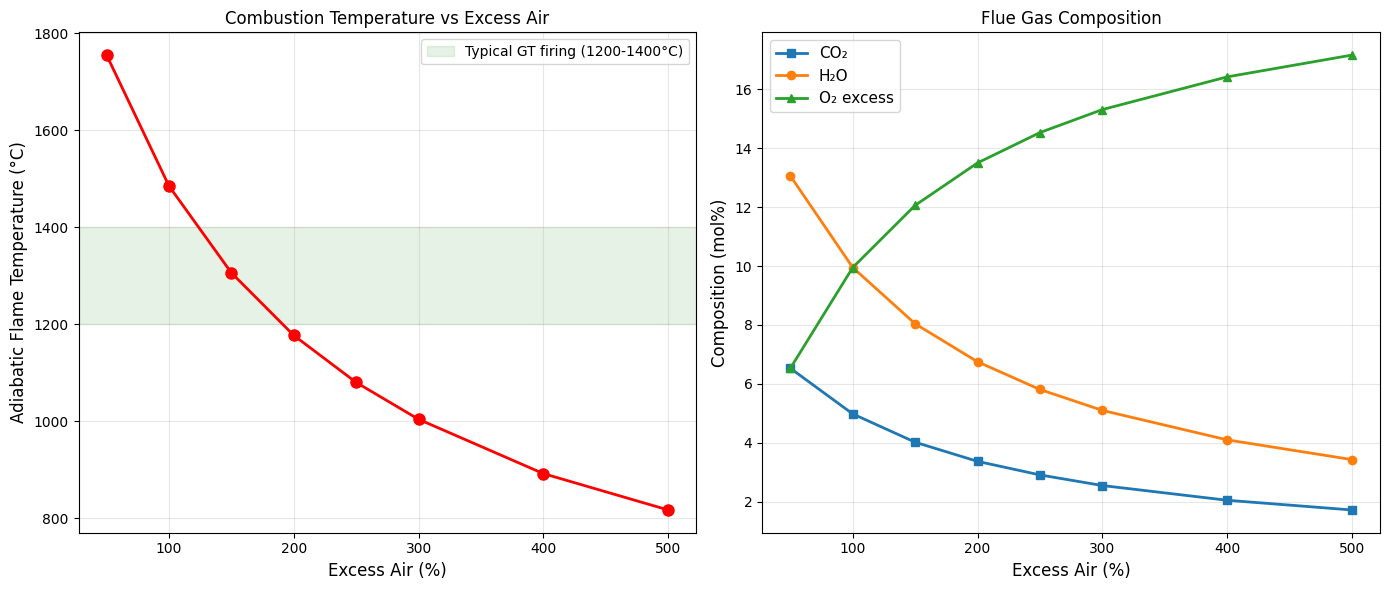

In [4]:
# Rigorous combustion with Gibbs reactor — excess air sweep
excess_air_pcts = [50, 100, 150, 200, 250, 300, 400, 500]
T_air_in = 400.0  # °C  (compressed air temperature)
P_comb = 18.0     # bara

combustion_results = []

for excess in excess_air_pcts:
    try:
        air_ratio = 1.0 + excess / 100.0
        # Stoichiometric: CH4 + 2 O2 -> CO2 + 2 H2O
        # In air: 2 mol O2 = 2/0.2095 = 9.55 mol air per mol CH4
        stoich_o2 = 2.0
        o2_moles = stoich_o2 * air_ratio
        n2_moles = o2_moles * (0.7812 / 0.2095)
        ar_moles = o2_moles * (0.0093 / 0.2095)

        comb_fluid = SystemSrkEos(273.15 + T_air_in, P_comb)
        comb_fluid.addComponent('methane', 1.0)
        comb_fluid.addComponent('nitrogen', n2_moles)
        comb_fluid.addComponent('oxygen', o2_moles)
        comb_fluid.addComponent('argon', ar_moles)
        comb_fluid.addComponent('CO2', 1e-10)  # product species (trace)
        comb_fluid.addComponent('water', 1e-10)
        comb_fluid.setMixingRule('classic')

        s = Stream('Premix', comb_fluid)
        s.setFlowRate(500000.0, 'kg/hr')
        s.setTemperature(T_air_in, 'C')
        s.setPressure(P_comb, 'bara')

        proc = ProcessSystem()
        proc.add(s)

        rx = GibbsReactor('Combustor', s)
        rx.setEnergyMode('adiabatic')
        rx.setMaxIterations(5000)
        proc.add(rx)
        proc.run()

        T_ad = float(rx.getOutletStream().getTemperature()) - 273.15
        out = rx.getOutletStream().getFluid()

        x_co2 = float(out.getPhase(0).getComponent('CO2').getx()) * 100
        x_h2o = float(out.getPhase(0).getComponent('water').getx()) * 100
        x_o2 = float(out.getPhase(0).getComponent('oxygen').getx()) * 100
        x_n2 = float(out.getPhase(0).getComponent('nitrogen').getx()) * 100
        x_ar = float(out.getPhase(0).getComponent('argon').getx()) * 100

        combustion_results.append({
            'Excess Air (%)': excess, 'Air Ratio': round(air_ratio, 2),
            'T_ad (°C)': round(T_ad, 0),
            'CO₂ (mol%)': round(x_co2, 2), 'H₂O (mol%)': round(x_h2o, 2),
            'O₂ (mol%)': round(x_o2, 2), 'N₂ (mol%)': round(x_n2, 1),
        })
    except Exception as e:
        combustion_results.append({
            'Excess Air (%)': excess, 'Air Ratio': round(air_ratio, 2),
            'T_ad (°C)': float('nan'), 'CO₂ (mol%)': float('nan'),
            'H₂O (mol%)': float('nan'), 'O₂ (mol%)': float('nan'),
            'N₂ (mol%)': float('nan'),
        })

df_comb = pd.DataFrame(combustion_results)
print('Combustion Equilibrium Results (Gibbs Reactor, adiabatic):')
print(df_comb.to_string(index=False))

# Plot: adiabatic flame temperature + flue gas composition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

valid = df_comb.dropna(subset=['T_ad (°C)'])
ax1.plot(valid['Excess Air (%)'], valid['T_ad (°C)'], 'r-o', linewidth=2, markersize=8)
ax1.axhspan(1200, 1400, alpha=0.1, color='green', label='Typical GT firing (1200-1400°C)')
ax1.set_xlabel('Excess Air (%)', fontsize=12)
ax1.set_ylabel('Adiabatic Flame Temperature (°C)', fontsize=12)
ax1.set_title('Combustion Temperature vs Excess Air')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2.plot(valid['Excess Air (%)'], valid['CO₂ (mol%)'], 's-', linewidth=2, label='CO₂')
ax2.plot(valid['Excess Air (%)'], valid['H₂O (mol%)'], 'o-', linewidth=2, label='H₂O')
ax2.plot(valid['Excess Air (%)'], valid['O₂ (mol%)'], '^-', linewidth=2, label='O₂ excess')
ax2.set_xlabel('Excess Air (%)', fontsize=12)
ax2.set_ylabel('Composition (mol%)', fontsize=12)
ax2.set_title('Flue Gas Composition')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('combustion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. HRSG Modeling with NeqSim HeatExchanger

Model the Heat Recovery Steam Generator (HRSG) using the NeqSim **HeatExchanger**
class with UA value. The hot side is the gas turbine exhaust; the cold side is water/steam.

The HeatExchanger supports:
- UA-based sizing (`setUAvalue`)
- Thermal effectiveness (`setThermalEffectiveness`)
- Counter-flow, parallel-flow, and shell-and-tube arrangements
- Entropy production and exergy analysis

In [5]:
# ============================================================
# HRSG: Use NeqSim HeatExchanger — Hot: GT exhaust, Cold: boiler feedwater
# ============================================================
# Hot side: gas turbine exhaust (from Section 2 above)
exhaust_fluid = SystemSrkEos(273.15 + T_exhaust, P_amb + 0.02)
exhaust_fluid.addComponent('nitrogen', 0.7812)
exhaust_fluid.addComponent('oxygen', 0.2095)
exhaust_fluid.addComponent('argon', 0.0093)
exhaust_fluid.setMixingRule('classic')

hot_stream = Stream('GT Exhaust', exhaust_fluid)
hot_stream.setFlowRate(air_flow, 'kg/hr')
hot_stream.setTemperature(T_exhaust, 'C')
hot_stream.setPressure(P_amb + 0.02, 'bara')

# Cold side: boiler feedwater (representing the HRSG/steam loop)
water_fluid = SystemSrkEos(273.15 + 80.0, 5.0)
water_fluid.addComponent('water', 1.0)
water_fluid.setMixingRule('classic')

cold_stream = Stream('Boiler Feedwater', water_fluid)
cold_stream.setFlowRate(100000.0, 'kg/hr')  # Steam generation rate
cold_stream.setTemperature(80.0, 'C')
cold_stream.setPressure(5.0, 'bara')

# Build HRSG process
hrsg_process = ProcessSystem()
hrsg_process.add(hot_stream)
hrsg_process.add(cold_stream)

# HeatExchanger with UA value
hrsg = HeatExchanger('HRSG', hot_stream, cold_stream)
hrsg.setUAvalue(500000.0)  # W/K — large for HRSG
hrsg.setFlowArrangement('counterflow')
hrsg_process.add(hrsg)

hrsg_process.run()

# Results
T_stack = float(hrsg.getOutStream(0).getTemperature()) - 273.15  # hot side out
T_steam = float(hrsg.getOutStream(1).getTemperature()) - 273.15  # cold side out
Q_hrsg = float(hrsg.getDuty()) / 1e6  # W -> MW
effectiveness = float(hrsg.getThermalEffectiveness())

print('=' * 55)
print('  HRSG — HEAT RECOVERY STEAM GENERATOR')
print('=' * 55)
print(f'  Hot side in:    {T_exhaust:.0f}°C  (GT exhaust)')
print(f'  Hot side out:   {T_stack:.0f}°C   (stack temperature)')
print(f'  Cold side in:   80°C      (feedwater)')
print(f'  Cold side out:  {T_steam:.0f}°C   (superheated steam)')
print(f'  Heat Duty:      {Q_hrsg:.1f} MW')
print(f'  UA value:       500,000 W/K')
print(f'  Thermal Effectiveness: {effectiveness:.3f}')
try:
    S_hrsg = float(hrsg.getEntropyProduction('J/K'))
    print(f'  Entropy Production:    {S_hrsg:.0f} J/K')
except Exception:
    pass

# Estimate steam turbine power from HRSG duty
eta_rankine = 0.33  # Rankine cycle efficiency
W_steam_MW = abs(Q_hrsg) * eta_rankine
W_cc_total = W_net / 1000 + W_steam_MW  # MW
eta_cc = W_cc_total / (abs(Q_comb) / 1000) * 100

print(f'\n--- Combined Cycle Totals ---')
print(f'  GT Net Power:       {W_net/1000:.1f} MW')
print(f'  Steam Turbine Power: {W_steam_MW:.1f} MW (est. η_Rankine = {eta_rankine})')
print(f'  CCGT Total Power:   {W_cc_total:.1f} MW')
print(f'  CCGT Efficiency:    {eta_cc:.1f}%')
print(f'  Heat Rate:          {3600/eta_cc*100:.0f} kJ/kWh')

  HRSG — HEAT RECOVERY STEAM GENERATOR
  Hot side in:    588°C  (GT exhaust)
  Hot side out:   167°C   (stack temperature)
  Cold side in:   80°C      (feedwater)
  Cold side out:  157°C   (superheated steam)
  Heat Duty:      -62.5 MW
  UA value:       500,000 W/K
  Thermal Effectiveness: 0.836
  Entropy Production:    175706 J/K

--- Combined Cycle Totals ---
  GT Net Power:       65.6 MW
  Steam Turbine Power: 20.6 MW (est. η_Rankine = 0.33)
  CCGT Total Power:   86.3 MW
  CCGT Efficiency:    57.7%
  Heat Rate:          6238 kJ/kWh


## 5. Exergy Analysis, Entropy Production & CO₂ Emissions

Use NeqSim's built-in **exergy** and **entropy production** methods to identify
the largest sources of irreversibility in the gas turbine cycle.

Also calculate **CO₂ emissions** using the `CombustionEmissionsCalculator`
and express them in industry-standard units (kg CO₂/MWh).

  EXERGY & ENTROPY PRODUCTION ANALYSIS
     Equipment  Entropy Prod (J/K)  Exergy Destruction (MJ)  Exergy Change (MJ)
Air Compressor       -2.182787e-11                     -0.0                51.5
     Combustor        1.418914e+05                     40.9               108.6
   Gas Turbine        1.590495e+04                      4.6              -121.7

Total System Entropy Production: 157796 J/K
Total Exergy Destruction:        45.5 MJ

  CO₂ EMISSIONS ANALYSIS
Estimated fuel rate:     12500 kg/hr
CO₂ emission rate:       36248 kg CO₂/hr
CO₂ intensity (GT only): 552 kg CO₂/MWh
CO₂ intensity (CCGT):    420 kg CO₂/MWh
  (Typical CCGT: 350-400 kg CO₂/MWh, Coal: 800-1000 kg CO₂/MWh)


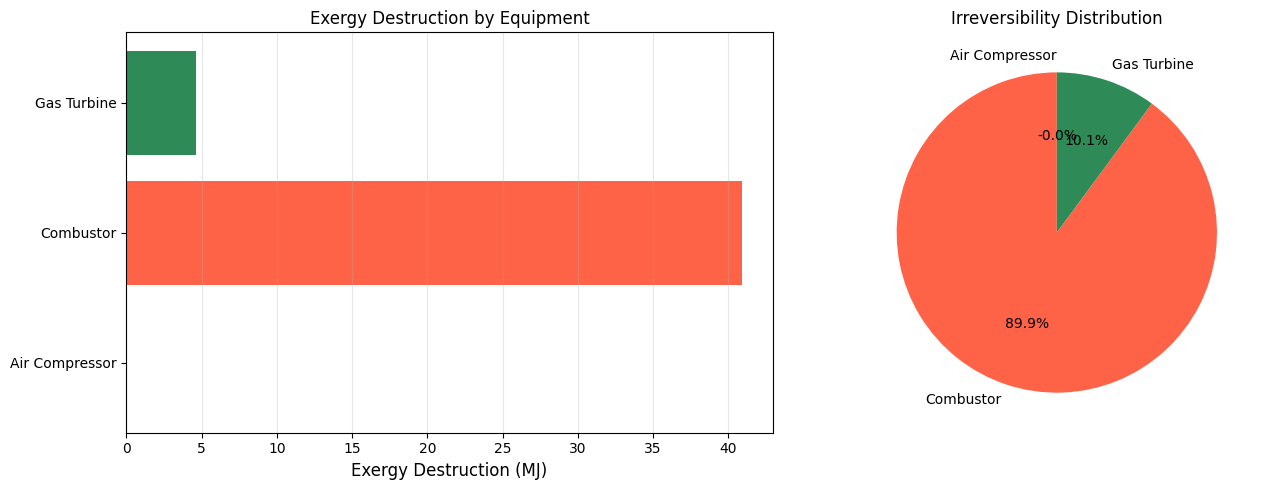

In [6]:
# ============================================================
# Exergy analysis — per equipment and system level
# ============================================================
print('=' * 60)
print('  EXERGY & ENTROPY PRODUCTION ANALYSIS')
print('=' * 60)

T_dead = 288.15  # dead state temperature (15°C in K)
equipment_list = [
    ('Air Compressor', comp),
    ('Combustor', combustor),
    ('Gas Turbine', turbine),
]

exergy_data = []
for name, eq in equipment_list:
    try:
        S_prod = float(eq.getEntropyProduction('J/K'))
    except Exception:
        S_prod = float('nan')
    try:
        Ex_change = float(eq.getExergyChange('J', T_dead))
    except Exception:
        Ex_change = float('nan')

    # Exergy destruction = T_dead * S_prod (Gouy-Stodola theorem)
    Ex_dest = T_dead * S_prod / 1e6 if not np.isnan(S_prod) else float('nan')

    exergy_data.append({
        'Equipment': name,
        'Entropy Prod (J/K)': S_prod,
        'Exergy Destruction (MJ)': round(Ex_dest, 1) if not np.isnan(Ex_dest) else float('nan'),
        'Exergy Change (MJ)': round(Ex_change / 1e6, 1) if not np.isnan(Ex_change) else float('nan'),
    })

df_exergy = pd.DataFrame(exergy_data)
print(df_exergy.to_string(index=False))

# Total system entropy production
try:
    S_total = float(gt_process.getEntropyProduction('J/K'))
    print(f'\nTotal System Entropy Production: {S_total:.0f} J/K')
    print(f'Total Exergy Destruction:        {T_dead * S_total / 1e6:.1f} MJ')
except Exception:
    pass

# ============================================================
# CO₂ Emissions (using CombustionEmissionsCalculator)
# ============================================================
print(f'\n{"=" * 60}')
print('  CO₂ EMISSIONS ANALYSIS')
print('=' * 60)

# Use the fuel stream from Section 1 and scale it
fuel_for_gt = SystemSrkEos(273.15 + 15.0, 30.0)
fuel_for_gt.addComponent('methane', 0.890)
fuel_for_gt.addComponent('ethane', 0.055)
fuel_for_gt.addComponent('propane', 0.018)
fuel_for_gt.addComponent('n-butane', 0.005)
fuel_for_gt.addComponent('i-butane', 0.003)
fuel_for_gt.addComponent('nitrogen', 0.015)
fuel_for_gt.addComponent('CO2', 0.014)
fuel_for_gt.setMixingRule('classic')

fuel_gt_stream = Stream('GT Fuel', fuel_for_gt)
# Estimated fuel flow: ~2-3% of air flow for gas turbines
fuel_rate_kg = air_flow * 0.025  # approximate fuel/air ratio ~2.5%
fuel_gt_stream.setFlowRate(fuel_rate_kg, 'kg/hr')
fuel_gt_stream.setTemperature(15.0, 'C')
fuel_gt_stream.setPressure(30.0, 'bara')
fuel_gt_stream.run()

# CombustionEmissionsCalculator is a measurement device — no run() needed
co2_calc_gt = CombustionEmissionsCalculator('GT CO2', fuel_gt_stream)
co2_emissions = float(co2_calc_gt.getMeasuredValue('kg/hr'))  # kg CO2/hr

# Express in common units
co2_per_mwh_gt = co2_emissions / (W_net / 1000) if W_net > 0 else 0
co2_per_mwh_cc = co2_emissions / W_cc_total if W_cc_total > 0 else 0

print(f'Estimated fuel rate:     {fuel_rate_kg:.0f} kg/hr')
print(f'CO₂ emission rate:       {co2_emissions:.0f} kg CO₂/hr')
print(f'CO₂ intensity (GT only): {co2_per_mwh_gt:.0f} kg CO₂/MWh')
print(f'CO₂ intensity (CCGT):    {co2_per_mwh_cc:.0f} kg CO₂/MWh')
print(f'  (Typical CCGT: 350-400 kg CO₂/MWh, Coal: 800-1000 kg CO₂/MWh)')

# Bar chart of exergy destruction
valid_ex = [d for d in exergy_data if not np.isnan(d.get('Exergy Destruction (MJ)', float('nan')))]
if valid_ex:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    names = [d['Equipment'] for d in valid_ex]
    ex_dest = [d['Exergy Destruction (MJ)'] for d in valid_ex]
    colors_bar = ['steelblue', 'tomato', 'seagreen']
    ax1.barh(names, ex_dest, color=colors_bar[:len(names)])
    ax1.set_xlabel('Exergy Destruction (MJ)', fontsize=12)
    ax1.set_title('Exergy Destruction by Equipment')
    ax1.grid(alpha=0.3, axis='x')

    # Pie chart of irreversibility distribution
    total_ex = sum(ex_dest)
    pcts = [e / total_ex * 100 for e in ex_dest]
    ax2.pie(pcts, labels=names, autopct='%1.1f%%', startangle=90,
            colors=['steelblue', 'tomato', 'seagreen'])
    ax2.set_title('Irreversibility Distribution')

    plt.tight_layout()
    plt.savefig('exergy_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Pressure Ratio & TIT Optimization

Systematically vary pressure ratio and turbine inlet temperature to map the
performance landscape. Also show the effect on combined cycle efficiency.

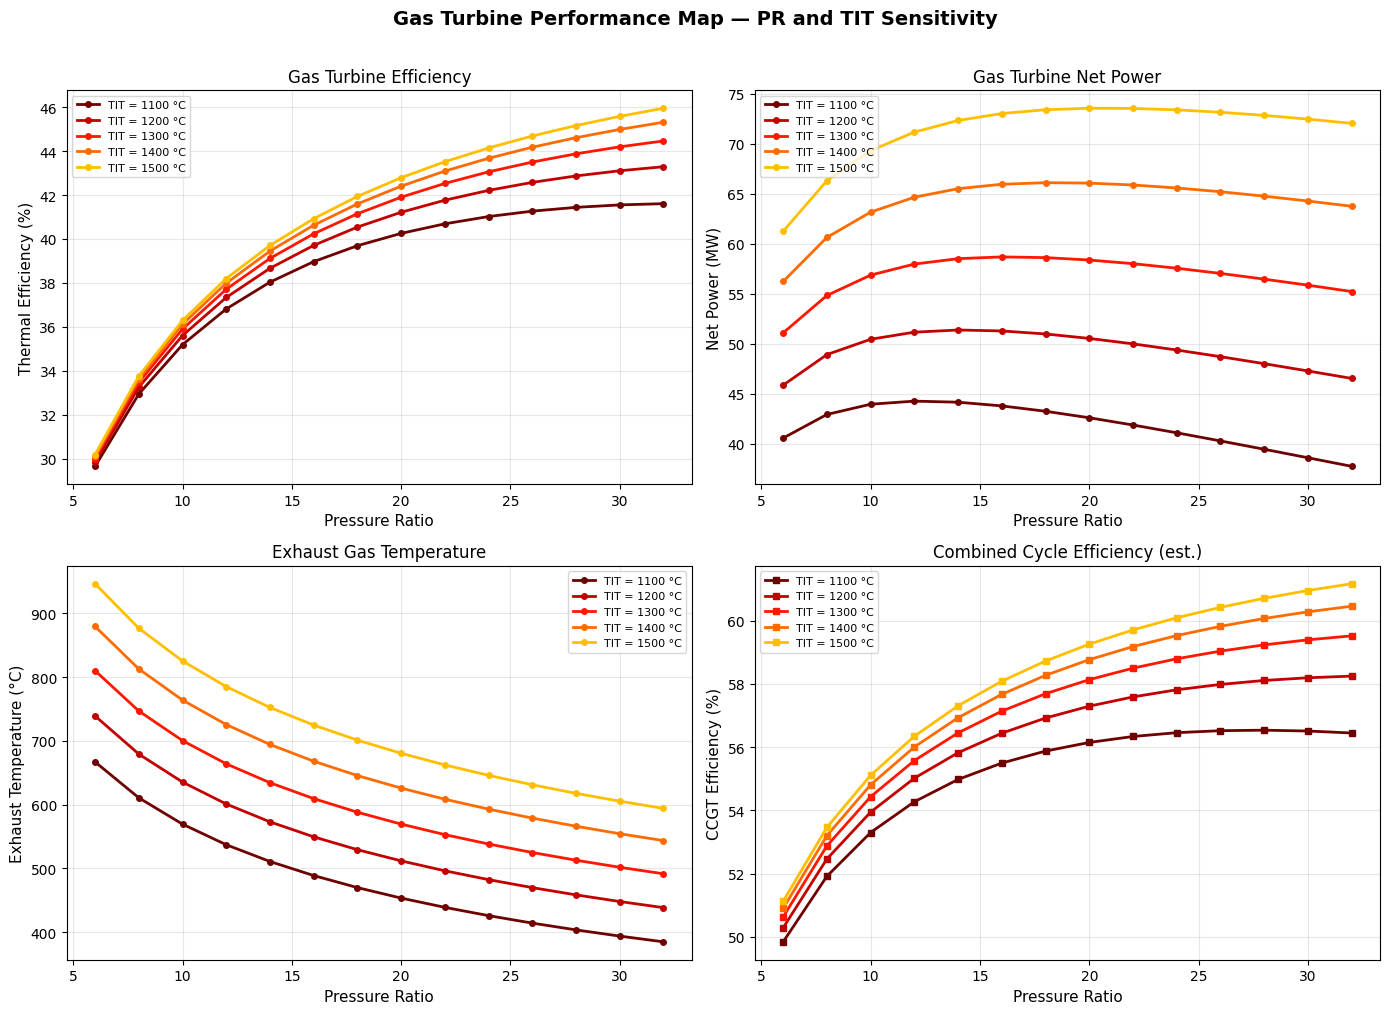


--- Optimal Pressure Ratio (max GT efficiency) ---
  TIT = 1100°C  →  PR_opt = 32, η_GT = 41.6%
  TIT = 1200°C  →  PR_opt = 32, η_GT = 43.3%
  TIT = 1300°C  →  PR_opt = 32, η_GT = 44.5%
  TIT = 1400°C  →  PR_opt = 32, η_GT = 45.3%
  TIT = 1500°C  →  PR_opt = 32, η_GT = 45.9%


In [7]:
# ============================================================
# Helper: simulate Brayton + CC at given PR, TIT, T_amb
# ============================================================
def simulate_brayton(PR=18.0, TIT_C=1300.0, eta_comp=0.88, eta_turb=0.90,
                     T_amb_C=15.0, P_amb=1.013, air_flow_kghr=500000.0):
    """Run a simple gas turbine and return key performance results."""
    air = SystemSrkEos(273.15 + T_amb_C, P_amb)
    air.addComponent('nitrogen', 0.7812)
    air.addComponent('oxygen', 0.2095)
    air.addComponent('argon', 0.0093)
    air.setMixingRule('classic')

    feed = Stream('Air', air)
    feed.setFlowRate(air_flow_kghr, 'kg/hr')
    feed.setTemperature(T_amb_C, 'C')
    feed.setPressure(P_amb, 'bara')

    proc = ProcessSystem()
    proc.add(feed)

    c = Compressor('C', feed)
    c.setOutletPressure(P_amb * PR)
    c.setIsentropicEfficiency(eta_comp)
    proc.add(c)

    h = Heater('H', c.getOutletStream())
    h.setOutTemperature(273.15 + TIT_C)
    proc.add(h)

    t = Expander('T', h.getOutletStream())
    t.setOutletPressure(P_amb + 0.02)
    t.setIsentropicEfficiency(eta_turb)
    proc.add(t)

    proc.run()

    W_c = abs(float(c.getPower('kW')))
    W_t = abs(float(t.getPower('kW')))
    Q = abs(float(h.getDuty()) / 1000.0)      # kW
    W_net = W_t - W_c
    T_exh = float(t.getOutletStream().getTemperature()) - 273.15
    eta_gt = W_net / Q * 100 if Q > 0 else 0

    # Combined cycle estimate (Rankine bottoming)
    Q_exhaust = Q - W_net
    Q_rec = Q_exhaust * max(0, (T_exh - 100)) / max(1, (T_exh - 15))
    W_steam = Q_rec * 0.33
    W_cc = W_net + W_steam
    eta_cc = W_cc / Q * 100 if Q > 0 else 0

    return {'PR': PR, 'TIT_C': TIT_C, 'T_amb_C': T_amb_C,
            'W_comp_kW': W_c, 'W_turb_kW': W_t, 'W_net_kW': W_net,
            'Q_kW': Q, 'eta_gt_pct': eta_gt, 'eta_cc_pct': eta_cc,
            'T_exhaust_C': T_exh, 'W_cc_kW': W_cc}

# ============================================================
# Sweep: PR at multiple TIT levels
# ============================================================
PRs = list(range(6, 34, 2))
TITs = [1100, 1200, 1300, 1400, 1500]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.hot(np.linspace(0.15, 0.65, len(TITs)))

for TIT_val, color in zip(TITs, colors):
    etas_gt, etas_cc, powers, t_exh_list = [], [], [], []
    for pr in PRs:
        try:
            r = simulate_brayton(PR=float(pr), TIT_C=float(TIT_val))
            etas_gt.append(r['eta_gt_pct'])
            etas_cc.append(r['eta_cc_pct'])
            powers.append(r['W_net_kW'] / 1000)
            t_exh_list.append(r['T_exhaust_C'])
        except Exception:
            etas_gt.append(float('nan'))
            etas_cc.append(float('nan'))
            powers.append(float('nan'))
            t_exh_list.append(float('nan'))

    label = f'TIT = {TIT_val} °C'
    axes[0, 0].plot(PRs, etas_gt, '-o', color=color, lw=2, ms=4, label=label)
    axes[0, 1].plot(PRs, powers, '-o', color=color, lw=2, ms=4, label=label)
    axes[1, 0].plot(PRs, t_exh_list, '-o', color=color, lw=2, ms=4, label=label)
    axes[1, 1].plot(PRs, etas_cc, '-s', color=color, lw=2, ms=4, label=label)

titles = ['Gas Turbine Efficiency', 'Gas Turbine Net Power',
          'Exhaust Gas Temperature', 'Combined Cycle Efficiency (est.)']
ylabels = ['Thermal Efficiency (%)', 'Net Power (MW)',
           'Exhaust Temperature (°C)', 'CCGT Efficiency (%)']
for ax, t, yl in zip(axes.flat, titles, ylabels):
    ax.set_xlabel('Pressure Ratio', fontsize=11)
    ax.set_ylabel(yl, fontsize=11)
    ax.set_title(t, fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Gas Turbine Performance Map — PR and TIT Sensitivity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gt_performance_map.png', dpi=150, bbox_inches='tight')
plt.show()

# Optimal PR for each TIT (max GT efficiency)
print('\n--- Optimal Pressure Ratio (max GT efficiency) ---')
for TIT_val in TITs:
    best_eta, best_pr = 0, 0
    for pr in PRs:
        try:
            r = simulate_brayton(PR=float(pr), TIT_C=float(TIT_val))
            if r['eta_gt_pct'] > best_eta:
                best_eta = r['eta_gt_pct']
                best_pr = pr
        except Exception:
            pass
    print(f'  TIT = {TIT_val}°C  →  PR_opt = {best_pr}, η_GT = {best_eta:.1f}%')

## 7. Ambient Temperature Derating

Gas turbine performance is sensitive to ambient temperature because:
- Higher $T_{amb}$ → lower air density → lower mass flow at fixed volumetric intake
- Higher compressor inlet temperature → more compressor work
- Both effects reduce net power output

Industry rule of thumb: **~0.7% power loss per °C** above ISO conditions (15°C).

We sweep ambient temperature from −10°C to +45°C at fixed PR and TIT to quantify
the derating using NeqSim's full thermodynamic model.

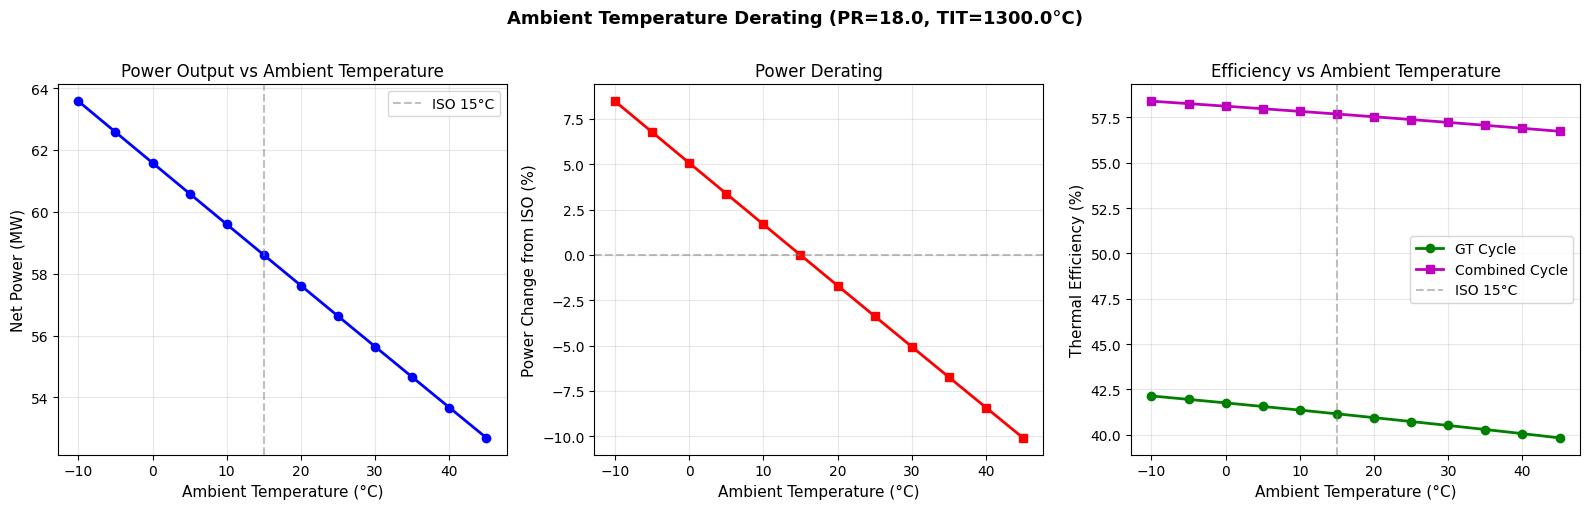


Derating coefficient: -198 kW/°C (-0.34%/°C)
Industry rule of thumb: ~0.7%/°C

--- Ambient Temperature Derating Data ---
 T_amb (°C)  W_net (MW)  Derate (%)  η_GT (%)  η_CC (%)  T_exh (°C)
      -10.0        63.6         8.5      42.1      58.4       588.0
       -5.0        62.6         6.8      41.9      58.3       588.0
        0.0        61.6         5.1      41.8      58.1       588.0
        5.0        60.6         3.4      41.6      58.0       588.0
       10.0        59.6         1.7      41.4      57.8       588.0
       15.0        58.6         0.0      41.1      57.7       588.0
       20.0        57.6        -1.7      40.9      57.5       588.0
       25.0        56.6        -3.4      40.7      57.4       588.0
       30.0        55.6        -5.1      40.5      57.2       588.0
       35.0        54.7        -6.7      40.3      57.1       588.0
       40.0        53.7        -8.4      40.1      56.9       588.0
       45.0        52.7       -10.1      39.8      56.7       

In [8]:
# ============================================================
# Ambient temperature derating study
# ============================================================
T_amb_range = np.arange(-10, 46, 5)
PR_fixed = 18.0
TIT_fixed = 1300.0

derate_results = []
for T_a in T_amb_range:
    try:
        r = simulate_brayton(PR=PR_fixed, TIT_C=TIT_fixed, T_amb_C=float(T_a))
        derate_results.append(r)
    except Exception:
        derate_results.append({'T_amb_C': float(T_a), 'W_net_kW': float('nan'),
                               'eta_gt_pct': float('nan'), 'eta_cc_pct': float('nan'),
                               'T_exhaust_C': float('nan')})

# Reference at ISO conditions
ref = [d for d in derate_results if abs(d['T_amb_C'] - 15.0) < 3]
W_ref = ref[0]['W_net_kW'] if ref else derate_results[5]['W_net_kW']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Power derating
powers_derate = [d['W_net_kW'] / 1000 for d in derate_results]
pct_derate = [(d['W_net_kW'] / W_ref - 1) * 100 for d in derate_results]
axes[0].plot(T_amb_range, powers_derate, 'b-o', lw=2, ms=6)
axes[0].axvline(15, color='gray', ls='--', alpha=0.5, label='ISO 15°C')
axes[0].set_xlabel('Ambient Temperature (°C)', fontsize=11)
axes[0].set_ylabel('Net Power (MW)', fontsize=11)
axes[0].set_title('Power Output vs Ambient Temperature')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Percentage derating
axes[1].plot(T_amb_range, pct_derate, 'r-s', lw=2, ms=6)
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Ambient Temperature (°C)', fontsize=11)
axes[1].set_ylabel('Power Change from ISO (%)', fontsize=11)
axes[1].set_title('Power Derating')
axes[1].grid(alpha=0.3)

# GT and CC efficiency
etas_gt_d = [d['eta_gt_pct'] for d in derate_results]
etas_cc_d = [d['eta_cc_pct'] for d in derate_results]
axes[2].plot(T_amb_range, etas_gt_d, 'g-o', lw=2, ms=6, label='GT Cycle')
axes[2].plot(T_amb_range, etas_cc_d, 'm-s', lw=2, ms=6, label='Combined Cycle')
axes[2].axvline(15, color='gray', ls='--', alpha=0.5, label='ISO 15°C')
axes[2].set_xlabel('Ambient Temperature (°C)', fontsize=11)
axes[2].set_ylabel('Thermal Efficiency (%)', fontsize=11)
axes[2].set_title('Efficiency vs Ambient Temperature')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'Ambient Temperature Derating (PR={PR_fixed}, TIT={TIT_fixed}°C)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ambient_derating.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify derating coefficient
valid_derate = [(d['T_amb_C'], d['W_net_kW']) for d in derate_results
                if not np.isnan(d['W_net_kW'])]
if len(valid_derate) > 2:
    temps = [v[0] for v in valid_derate]
    pows = [v[1] for v in valid_derate]
    slope = np.polyfit(temps, pows, 1)[0]  # kW per °C
    slope_pct = slope / W_ref * 100
    print(f'\nDerating coefficient: {slope:.0f} kW/°C ({slope_pct:.2f}%/°C)')
    print(f'Industry rule of thumb: ~0.7%/°C')

# Table of results
print('\n--- Ambient Temperature Derating Data ---')
df_derate = pd.DataFrame([{
    'T_amb (°C)': d['T_amb_C'],
    'W_net (MW)': round(d['W_net_kW'] / 1000, 1),
    'Derate (%)': round((d['W_net_kW'] / W_ref - 1) * 100, 1),
    'η_GT (%)': round(d['eta_gt_pct'], 1),
    'η_CC (%)': round(d['eta_cc_pct'], 1),
    'T_exh (°C)': round(d['T_exhaust_C'], 0),
} for d in derate_results if not np.isnan(d['W_net_kW'])])
print(df_derate.to_string(index=False))

## Summary

This notebook demonstrated a **comprehensive gas turbine and combined cycle simulation**
using NeqSim's process simulation capabilities:

| Section | NeqSim Feature | Key Output |
|---------|----------------|------------|
| 1. Fuel Gas | `Standard_ISO6976`, `CombustionEmissionsCalculator` | GCV, NCV, Wobbe Index, CO₂ rate |
| 2. Brayton Cycle | `Compressor` (polytropic), `Expander`, `Heater` | Power, efficiency, fluid properties |
| 3. Combustion | `GibbsReactor` (adiabatic) | Flame temperature, equilibrium composition |
| 4. HRSG | `HeatExchanger` (UA, counterflow) | Thermal effectiveness, CC efficiency |
| 5. Exergy | `getEntropyProduction()`, `getExergyChange()` | Irreversibility maps, CO₂ intensity |
| 6. Optimization | Parametric sweeps | PR/TIT performance map |
| 7. Derating | Ambient temperature sweep | Power loss coefficient (%/°C) |

### Key NeqSim Classes Used
- `SystemSrkEos` — SRK equation of state for air, fuel gas, combustion products
- `Compressor` — polytropic mode, head, exponent, entropy production
- `Expander` — gas turbine modeling with isentropic efficiency
- `Heater` — combustor duty calculation
- `HeatExchanger` — HRSG with UA sizing and thermal effectiveness
- `GibbsReactor` — Gibbs equilibrium for combustion
- `Standard_ISO6976` — Fuel gas quality per ISO 6976
- `CombustionEmissionsCalculator` — CO₂ emissions from fuel
- `ProcessSystem` — system-level entropy production and exergy analysis
- Fluid: `getCp()`, `getCv()`, `getKappa()`, `getSoundSpeed()`, `getDensity()`